# FAST AEP USING FLOWERS

FLOWERS is an AEP model which efficiently computes a wind farm's AEP. It uses numerous simplifications and assumptions, but most importantly a Fourier transform turning discrete components, functions of wind direction, into a continuous function. From this, it  solves the integral analytically, rather than   numerically, also enabling the computation of analytical gradients.

Here a step by step guide to all of its functionalities, consisting of the computation of wind farm AEP , gradients, specific turbine AEP and plotting. 

### Package imports

Import FLOWERS wind farm models for different deficit models

In [1]:
from FLOWERS import NOJ_flowers, gaussian_flowers, TurbOPark_flowers, fuga_flowers

Other imports needed

In [2]:
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from py_wake.literature.noj import Jensen_1983
from topfarm import TopFarmProblem
from topfarm.easy_drivers import EasyScipyOptimizeDriver
import time
import matplotlib.pyplot as plt

# Ignore numerical errors coming from FLOWERS (division by zero, etc.)
import warnings
warnings.filterwarnings("ignore")

### Initialize AEP conditions

In [3]:
site = Hornsrev1Site()
turbine = V80()
x, y = site.initial_position.T

# Wake expansion coefficients
k_NOJ = 0.04
k_gaussian = 0.03

# Turbulence intensity for TurbOPark model
TI = 0.1

### Create wind farm models
The number of Fourier terms (`n_terms`) determines the accuracy of the model, as well as the computational time. A value of `n_terms = 10` is recommened by the original paper as the balance between the two. The maximum number of Fourier modes is given by the number of wind directions in the windrose, and is obtained as `N_wd//2 + 1`. HornsrevSite has 12 wind direction bins, so in this case, the maximum number is 7.

In [4]:
# NO Jensen wake model
wfm_NOJ = NOJ_flowers(site = site,
                      windTurbines = turbine,
                      k = k_NOJ,
                      n_terms = 7)

# Gaussian wake model
wfm_gaussian = gaussian_flowers(site = site,
                               windTurbines = turbine,
                               k = k_gaussian,
                               n_terms = 7)

# TurbOPark model
wfm_TurbOPark = TurbOPark_flowers(site = site,
                                 windTurbines = turbine,
                                 n_terms = 7,
                                 ti = TI)

# Fuga model
wfm_fuga = fuga_flowers(site = site,
                        windTurbines = turbine,
                        n_terms = 7)

### Compute wind farm AEP
The wind farm AEP is computed for a set of x and y coordinates defining the wind turbine positions, by means of the `aep` function. NOJ and TurbOPark FLOWERS have been found to underestimate AEP, while Gaussian is known to overestimate it. FLOWERS is not meant to compute AEP accurately, but to reflect the windfarm's dynamics for layout optimization purposes.

In [5]:
AEP_NOJ = wfm_NOJ.aep(x, y)

print(f"AEP NOJ: {AEP_NOJ:.2f} GWh")

AEP_gaussian = wfm_gaussian.aep(x, y)

print(f"AEP Gaussian: {AEP_gaussian:.2f} GWh")

AEP_TurbOPark = wfm_TurbOPark.aep(x, y)
print(f"AEP TurbOPark: {AEP_TurbOPark:.2f} GWh")

AEP_fuga = wfm_fuga.aep(x, y)
print(f"AEP Fuga: {AEP_fuga:.2f} GWh")

AEP NOJ: 539.52 GWh
AEP Gaussian: 783.08 GWh
AEP TurbOPark: 582.71 GWh
AEP Fuga: 119.95 GWh


### Compute gradients
Given that the AEP is computed solving the AEP integral anallytically rather than numerically, it enables the derivation of analytical gradients. Nevertheless, these are only available for NO Jensen and TurbOPark. 

The package can derive the gradients using automatic differentiation with the Autograd package (https://github.com/HIPS/autograd) for all FLOWERS models, but they can also be obtained by means of the analytically derived gradients.

Gradients are obtained by means of the `aep_gradient` function, using `gradient_method="Exact"` for analytical gradients (not implemented yet to Fuga FLOWERS) and `gradient_method="Autograd"` for automatic differentiation. It can be chosen whether the user wants to return the function computing the gradients, where the `x` and `y` inputs are left as `None`, or the gradients evaluated at certain coordinates, by providing the specific coordinates. Moreover, the package supports derivation with respect to x (`wrt_arg=["x"]`), y (`wrt_arg=["y"]`) or both (`wrt_arg=["x","y"]`).

#### Using automatic differentiation

In [6]:
# With respect to x and y - Evaluating the gradient
# NO Jensen
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian, daep_dy_gaussian = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
# TurbOPark
daep_dx_TurbOPark, daep_dy_TurbOPark = wfm_TurbOPark.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)

# With respect to x only - Evaluating the gradient
# NO Jensen
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)
# TurbOPark
daep_dx_TurbOPark = wfm_TurbOPark.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)

# With respect to y only - Returning the gradient function
# NO Jensen
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)
# Gaussian Bastankhah
daep_dy_gaussian_func = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_gaussian = daep_dy_gaussian_func(x, y)
# TurbOPark
daep_dy_TurbOPark_func = wfm_TurbOPark.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_TurbOPark = daep_dy_TurbOPark_func(x, y)

#### Using analytical gradients

In [7]:
# With respect to x and y - Evaluating the gradient
# NO Jensen
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
# TurbOPark
daep_dx_TurbOPark, daep_dy_TurbOPark = wfm_TurbOPark.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian, daep_dy_gaussian = wfm_gaussian.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)

# With respect to x only - Evaluating the gradient
# No Jensen
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)
# TurbOPark
daep_dx_TurbOPark = wfm_TurbOPark.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)
# Gaussian Bastankhah
daep_dx_gaussian = wfm_gaussian.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)

# With respect to y only - Returning the gradient function
# NO Jensen
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)
# TurbOPark
daep_dy_TurbOPark_func = wfm_TurbOPark.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_TurbOPark = daep_dy_TurbOPark_func(x, y)
# Gaussian Bastankhah
daep_dy_gaussian_func = wfm_gaussian.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_gaussian = daep_dy_gaussian_func(x, y)

#### Gradient methods comparison
Both Automatic and analytical differentiation are faster than other gradient computation methods such as finite differences. However there are slight numerical differences between the two in the case of NO Jensen

In [8]:
# Gradient for NOJ using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for NOJ using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for NOJ model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0110 seconds
Time taken for autograd gradient: 0.0118 seconds

Comparing gradients for NOJ model:
Gradient (Exact) - daep_dx: [-0.00272678 -0.00297185 -0.00308627]
Gradient (Exact) - daep_dy: [0.00247404 0.00082243 0.00024209]
Gradient (Autograd) - daep_dx: [-0.00272952 -0.00297314 -0.00308732]
Gradient (Autograd) - daep_dy: [0.00247518 0.00082432 0.00024409]


In [9]:
# Gradient for TurbOPark using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_TurbOPark.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for TurbOPark using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_TurbOPark.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for TurbOPark model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0127 seconds
Time taken for autograd gradient: 0.0118 seconds

Comparing gradients for TurbOPark model:
Gradient (Exact) - daep_dx: [-0.00208796 -0.00224497 -0.00233541]
Gradient (Exact) - daep_dy: [0.00179523 0.00068095 0.00026509]
Gradient (Autograd) - daep_dx: [-0.00208796 -0.00224497 -0.00233541]
Gradient (Autograd) - daep_dy: [0.00179523 0.00068095 0.00026509]


In [10]:
# Gradient for Gaussian using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_gaussian.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for Gaussian using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_gaussian.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for Gaussian model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0043 seconds
Time taken for autograd gradient: 0.0063 seconds

Comparing gradients for Gaussian model:
Gradient (Exact) - daep_dx: [-9.78874559e-07 -1.06349596e-06 -1.08202641e-06]
Gradient (Exact) - daep_dy: [6.85012375e-07 1.48439755e-07 1.14334188e-08]
Gradient (Autograd) - daep_dx: [-9.78874559e-07 -1.06349596e-06 -1.08202641e-06]
Gradient (Autograd) - daep_dy: [6.85012375e-07 1.48439755e-07 1.14334188e-08]


### AEP for a specific turbine
FLOWERS supports the calculation of the AEP for a specific wind turbine from the wind farm, using the `aep_i` function.

(It should be checked how useful this is, especially for Gaussian)

In [11]:
turbine_number = 63

# NO Jensen AEP for turbine 63
aep_63_NOJ = wfm_NOJ.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using NOJ: {aep_63_NOJ:.2f} GWh")

# Gaussian Bastankhah AEP for turbine 63
aep_63_gaussian = wfm_gaussian.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using Gaussian: {aep_63_gaussian:.2f} GWh")

# TurbOPark AEP for turbine 63
aep_63_TurbOPark = wfm_TurbOPark.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using TurbOPark: {aep_63_TurbOPark:.2f} GWh")

# Fuga AEP for turbine 63
aep_63_fuga = wfm_fuga.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using Fuga: {aep_63_fuga:.2f} GWh")

AEP for turbine 63 using NOJ: 7.48 GWh
AEP for turbine 63 using Gaussian: 9.79 GWh
AEP for turbine 63 using TurbOPark: 7.90 GWh
AEP for turbine 63 using Fuga: 2.01 GWh


#### Plotting AEP for each turbine

It is possible to plot the wind farm and the AEP coming from each turbine using the `plot_AEP_per_turbine` function.

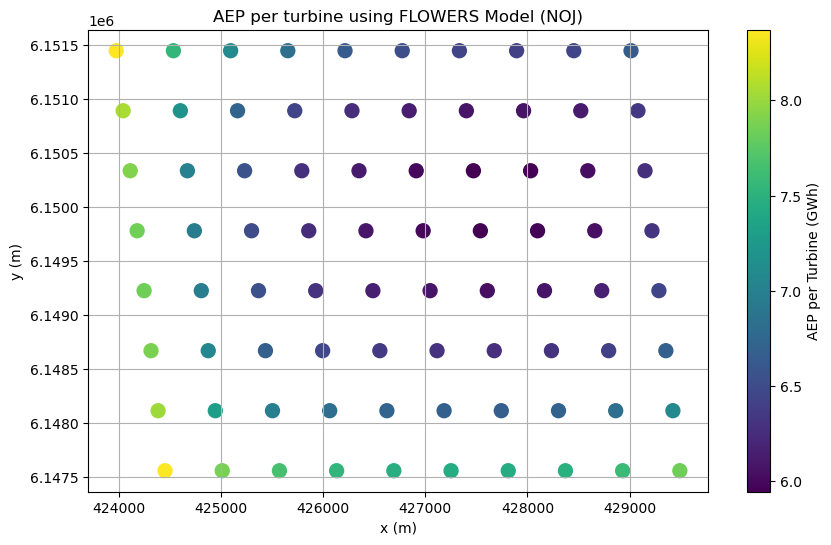

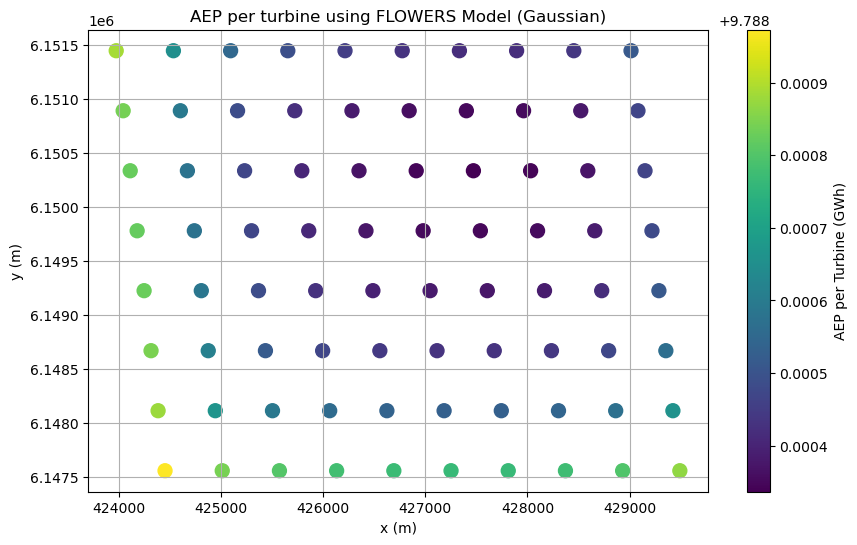

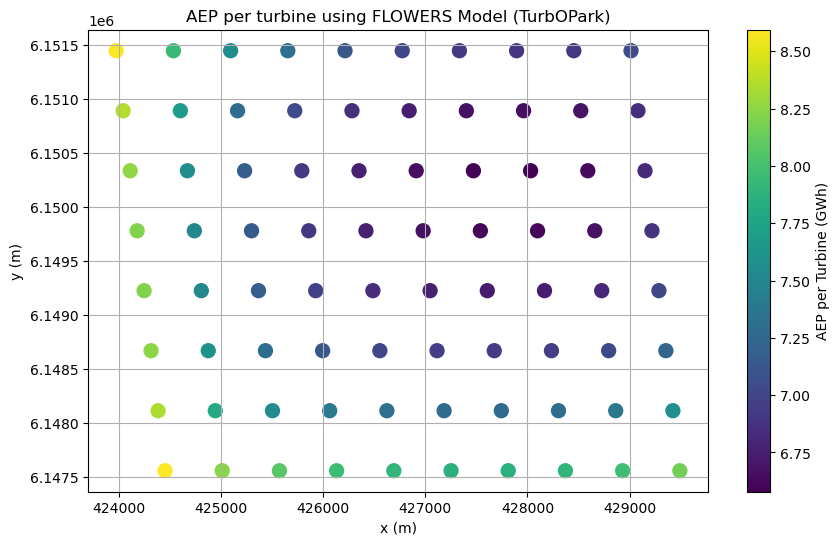

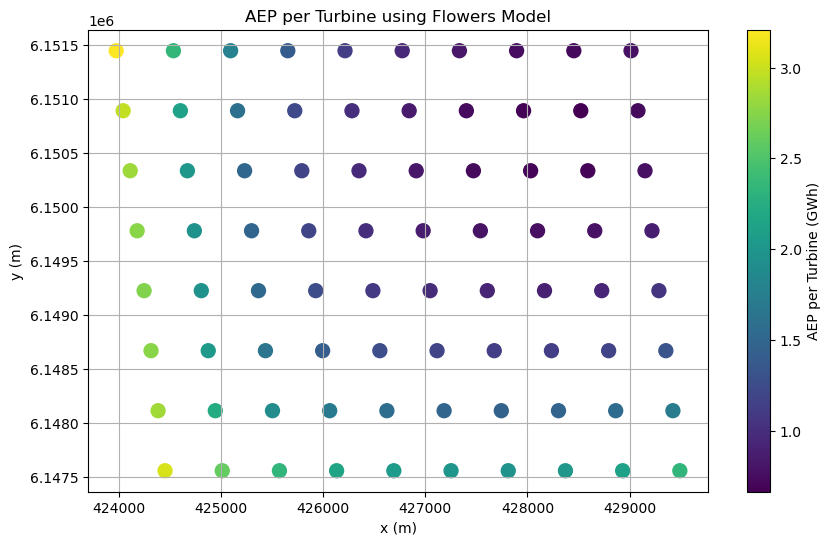

In [12]:
# Plotting AEP per turbine for NOJ model
wfm_NOJ.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for Gaussian model
wfm_gaussian.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for TurbOPark model
wfm_TurbOPark.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for Fuga model
wfm_fuga.plot_AEP_per_turbine(x, y)

### WFLO using TopFarm example

The main reason to develop and use a model such as FLOWERS is to efficiently optimize wind farm layouts. Thanks to its fast AEP and gradients computation, WFLO problems can be quickly solved. The code below provides an example using NO Jensen FLOWERS with exact analytical gradients, for Horns Rev, with 80 turbines.
To evaluate the initial and optimized layout, PyWake is used, given that FLOWERS is not meant to compute AEP accurately.

In [ ]:
# Set up wind farm model
wfm = Jensen_1983(site=site, windTurbines=turbine, k=0.04)

sim_res = wfm(x, y,
            wd=site.default_wd,
            ws=site.default_ws)

initial_aep = sim_res.aep().sum().values

##### Create TopFarm problem

In [ ]:
# AEP function
def aep_func(x, y):
    return wfm_NOJ.aep(x, y)

# AEP gradients
def aep_gradient(x, y):
    return wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)

# Setup constraints
min_dist = 5*turbine.diameter()
turb_sep_constraint = SpacingConstraint(min_dist)
boundary = [[x.min(), y.min()], [x.max(), y.min()], [x.max(), y.max()], [x.min(), y.max()], [x.min(), y.min()]]
boundary_constraint = XYBoundaryConstraint(boundary)

constraints = [turb_sep_constraint, boundary_constraint]

# Setup cost component
aep_comp = CostModelComponent(input_keys=[('x', x),('y', y)],
                              n_wt=len(x),
                              cost_function=aep_func,
                              cost_gradient_function=aep_gradient,
                              maximize=True,
                              objective=True,
                              output_keys=['AEP'])

# Set up driver
driver = EasyScipyOptimizeDriver(optimizer="SLSQP",
                                 maxiter=50,
                                 tol=1)

# Set up optimization problem
topfarm_problem = TopFarmProblem(design_vars=dict(zip(['x', 'y'], [x, y])),
                                 cost_comp=aep_comp,
                                 driver=driver,
                                 constraints=constraints,
                                 n_wt=len(x),
                                 expected_cost=1e-5)

##### Run the optimization

In [ ]:
time_start = time.time()
print("Starting optimization...")
_, state, recorder = topfarm_problem.optimize()
time_end = time.time()

Starting optimization...
Iteration limit reached    (Exit mode 9)
            Current function value: -56573226.529312424
            Iterations: 50
            Function evaluations: 54
            Gradient evaluations: 51
Optimization FAILED.
Iteration limit reached
-----------------------------------


##### Results

Initial AEP from flow model: 661.93 GWh
Optimization completed in 13.25 seconds
Final AEP from flow model: 670.13


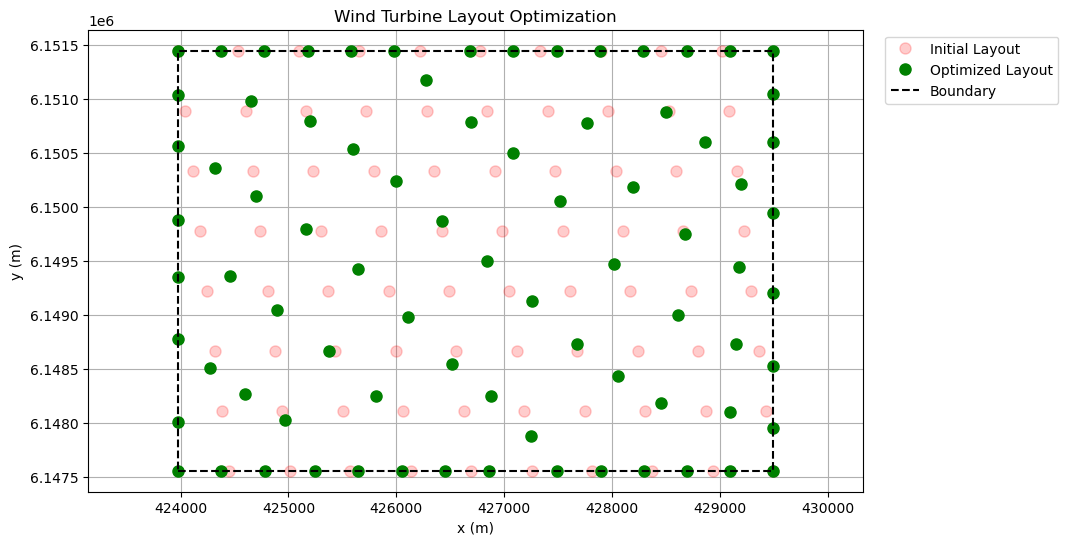

In [ ]:
x_opt = state["x"]
y_opt = state["y"]

# Evaluate final layout using PyWake
sim_res = wfm(x_opt, y_opt,
            wd=site.default_wd,
            ws=site.default_ws)

final_aep = sim_res.aep().sum().values

print(f"Initial AEP from flow model: {initial_aep:.2f} GWh")
print(f"Optimization completed in {time_end - time_start:.2f} seconds")
print(f"Final AEP from flow model: {final_aep:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='Initial Layout', markersize=8, alpha=0.2)
plt.plot(x_opt, y_opt, 'go', label='Optimized Layout', markersize=8)
plt.plot([limit[0] for limit in boundary], [limit[1] for limit in boundary], 'k--', label='Boundary')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Wind Turbine Layout Optimization')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.grid()